# BeeQeeper — Phase 0: Exploratory Data Analysis

This notebook characterizes the **X10 molecular representation** before the main model comparison. The objective is not to choose the “best” classifier from the plots, but to understand:

- which descriptors contain toxicity-related signal;
- which descriptors are redundant or unusually sparse;
- what the main linear and nonlinear directions of variation look like;
- whether molecular structural families are associated with the label;
- and how different the DEVELOPMENT and TEST domains are.

Unless stated otherwise, **label-informed analyses are performed on DEVELOPMENT only**. TEST is used here for feature-space and structural-novelty diagnostics, not to make new feature decisions from its labels.


## Setup

Load the curated `master.csv`, define the ten X10 descriptors, and separate the **712 DEVELOPMENT** molecules from the **181 TEST** molecules.

DEVELOPMENT contains 222 toxic molecules (31.2%) and 490 non-toxic molecules (68.8%), so the classification problem is moderately imbalanced. This will matter later for model evaluation, but it does not require artificially balancing the data during EDA.

> The notebook expects `master.csv` to be available in the working directory.


In [5]:
%pip install pandas scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif


SEED = 42

df = pd.read_csv("../data/raw/master.csv")

FEATURES = [
    "MolLogP",
    "MolWt",
    "TPSA_SP",
    "NumHDonors",
    "NumRotatableBonds",
    "NumAromaticRings",
    "nHalogen",
    "n_OP",
    "LiPHEX_prediction",
    "sasa002_frac_polar_hetero_only",
]

dev = df[df["SET"] == "DEVELOPMENT"].copy()
test = df[df["SET"] == "TEST"].copy()

X = dev[FEATURES]
y = dev["LABEL"]

print(df.shape)
print(dev.shape, test.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

(893, 19)
(712, 19) (181, 19)
LABEL
0    490
1    222
Name: count, dtype: int64
LABEL
0    0.688202
1    0.311798
Name: proportion, dtype: float64


## 1. Dataset integrity and basic descriptive statistics

**Why:** before dimensionality reduction or modeling, we need to know the scale, type, sparsity, skewness, missingness, and range of each descriptor. These properties determine which visualizations and statistical summaries are appropriate.


In [7]:
summary = pd.DataFrame({
    "dtype": dev[FEATURES].dtypes,
    "missing": dev[FEATURES].isna().sum(),
    "unique": dev[FEATURES].nunique(),
    "mean": dev[FEATURES].mean(),
    "std": dev[FEATURES].std(),
    "min": dev[FEATURES].min(),
    "median": dev[FEATURES].median(),
    "max": dev[FEATURES].max(),
    "skew": dev[FEATURES].skew(),
})

summary

,dtype,missing,unique,mean,std,min,median,max,skew
MolLogP,float64,0,707,2.962598,1.874700,-8.161100,2.944950,9.998500,-0.681998
MolWt,float64,0,686,311.075770,111.600492,42.041000,303.580500,886.133000,0.894892
TPSA_SP,float64,0,444,73.774860,46.150482,0.000000,65.800000,336.430000,1.094496
NumHDonors,int64,0,11,0.842697,1.280813,0.000000,1.000000,12.000000,3.880727
NumRotatableBonds,int64,0,18,4.539326,2.966503,0.000000,4.000000,22.000000,0.852278
NumAromaticRings,int64,0,6,1.276685,0.929659,0.000000,1.000000,5.000000,0.287634
nHalogen,int64,0,12,1.245787,1.933489,0.000000,0.000000,17.000000,2.485298
n_OP,int64,0,3,0.129213,0.352033,0.000000,0.000000,2.000000,2.596332
LiPHEX_prediction,float64,0,711,0.302571,1.368061,-4.225155,0.202460,6.554141,0.582916
sasa002_frac_polar_hetero_only,float64,0,690,0.166373,0.088687,0.000000,0.154223,0.443211,0.394717


### Interpretation

- All ten X10 descriptors are complete in DEVELOPMENT: **no missing values** are present.
- The representation mixes continuous physicochemical variables with discrete molecular counts.
- Several variables are strongly skewed, particularly `NumHDonors`, `nHalogen`, and `n_OP`.
- `n_OP` has only three observed values (0, 1, 2), so treating it as an ordinary continuous feature in descriptive plots can be misleading.
- The long tails reinforce the decision to inspect extreme molecules and to use rank-based summaries such as Spearman correlation where appropriate.


### Inspect extreme values

**Why:** extreme descriptor values can strongly affect scaling, PCA, distances, and some models. In molecular data, however, an “outlier” may be a perfectly valid but unusual chemical, so extreme values should be inspected rather than removed automatically.


In [48]:
for feature in FEATURES:
    print(f"\n### {feature}")
    display(
        dev.nlargest(5, feature)[
            ["name", "SMILES", "LABEL", feature]
        ]
    )


### MolLogP


,name,SMILES,LABEL,MolLogP
60,Pentacosane,CCCCCCCCCCCCCCCCCCCCCCCCC,0,9.99850
293,Muscalure,CCCCCCCCC=CCCCCCCCCCCCCC,0,8.99430
885,Broflanilide (Ref: MCI-8007),CN(C(=O)c1ccccc1)c1cccc(C(=O)Nc2c(Br)cc(C(F)(C...,1,8.42530
410,"3-[2-Chloro-2-(4-chlorophenyl)ethenyl]-2,2-dim...",CC1(C)C(C=C(Cl)c2ccc(Cl)cc2)C1C(=O)OC(C#N)c1cc...,1,7.93138
375,Dienochlor (Ref: SAN 804),ClC1=C(Cl)C(Cl)(C2(Cl)C(Cl)=C(Cl)C(Cl)=C2Cl)C(...,0,7.72560



### MolWt


,name,SMILES,LABEL,MolWt
693,Emamectin benzoate (Ref: MK 244),CCC(C)C1OC2(C=CC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(O...,1,886.133
103,Abamectin (Ref: MK 936),CCC(C)C1OC2(C=CC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(O...,1,873.090
710,Spinetoram,CCOC1C(OC)C(C)OC(OC2CC3CCC4C5CC(=O)OC(CC)CCCC(...,1,748.011
874,Spinosad (Ref: XDE 105),CCC1CCCC(OC2CCC(N(C)C)C(C)O2)C(C)C(=O)C2=CC3C(...,1,745.995
690,Dihydroazadirachtin,CC=C(C)C(=O)OC1CC(OC(C)=O)C2(C(=O)OC)COC3C2C12...,0,722.737



### TPSA_SP


...

,name,SMILES,LABEL,n_OP
36,Tetraethyl ester diphosphoric acid,CCOP(=O)(OCC)OP(=O)(OCC)OCC,1,2
67,Ethion (Ref: ENT 24105),CCOP(=S)(OCC)SCSP(=S)(OCC)OCC,1,2
134,"O,O'-(Thiodi-4,1-phenylene) O,O,O',O'-tetramet...",COP(=S)(OC)Oc1ccc(Sc2ccc(OP(=S)(OC)OC)cc2)cc1,1,2
142,"Thiodiphosphoric acid, Tetrapropyl ester",CCCOP(=S)(OCCC)OP(=S)(OCCC)OCCC,0,2
4,"S-[(1,3-Dihydro-1,3-dioxo-2H-isoindol-2-yl)met...",COP(=S)(OC)SCN1C(=O)c2ccccc2C1=O,1,1



### LiPHEX_prediction


,name,SMILES,LABEL,LiPHEX_prediction
60,Pentacosane,CCCCCCCCCCCCCCCCCCCCCCCCC,0,6.554141
293,Muscalure,CCCCCCCCC=CCCCCCCCCCCCCC,0,6.084965
867,Di-1-p-menthene,CC1=CCC(CCC(C)(C)C2CC=C(C)CC2)CC1,0,5.446951
140,"1,1'-(2,2-Dichloroethylidene)bis[4-ethylbenzene",CCc1ccc(C(c2ccc(CC)cc2)C(Cl)Cl)cc1,1,5.031568
120,"(1R,4S,4aS,5S,8R,8aR)-rel-1,2,3,4,10,10-Hexach...",ClC1=C(Cl)C2(Cl)C3C4C=CC(C4)C3C1(Cl)C2(Cl)Cl,1,4.672992



### sasa002_frac_polar_hetero_only


,name,SMILES,LABEL,sasa002_frac_polar_hetero_only
136,Fosetyl,CCO[P+](=O)[O-],0,0.443211
160,"Phosphorodithioic acid S-[(5-methoxy-2-oxo-1,3...",COc1nn(CSP(=S)(OC)OC)c(=O)s1,1,0.416155
88,DNOC (Ref: ENT 154),Cc1cc([N+](=O)[O-])cc([N+](=O)[O-])c1O,0,0.414947
511,Thifensulfuron (Ref: IN L9225),COc1nc(C)nc(NC(=O)NS(=O)(=O)c2ccsc2C(=O)O)n1,1,0.412693
727,Thiencarbazone,COc1nn(C(=O)NS(=O)(=O)c2c(C(=O)O)csc2C)c(=O)n1C,0,0.400806


The largest values show that several descriptors have long tails (for example molecular weight, hydrogen-bond donors, rotatable bonds, and halogen count).

A molecular value that looks statistically extreme is not automatically an error. In QSAR, the first question is:

> **Is this an invalid record, or simply an unusual but valid molecule?**

For that reason, no IQR-based or z-score-based deletion is performed here.


## 2. Descriptor distributions by toxicity

**Why:** these class-conditional distributions provide a first view of whether toxic and non-toxic molecules occupy different regions of each descriptor.

The histograms use **density**, not raw counts, so the shapes of the two classes can be compared despite the class imbalance. They are descriptive only; overlapping distributions do not imply that a feature is useless in a multivariate model.


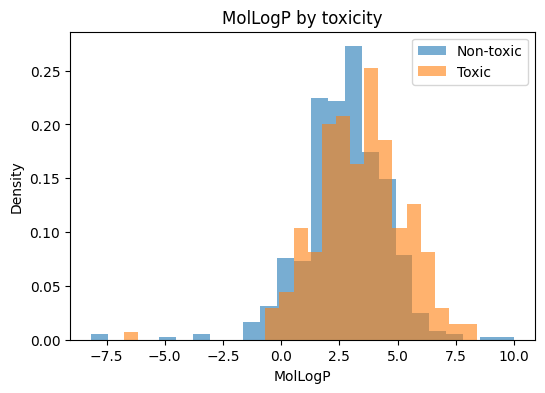

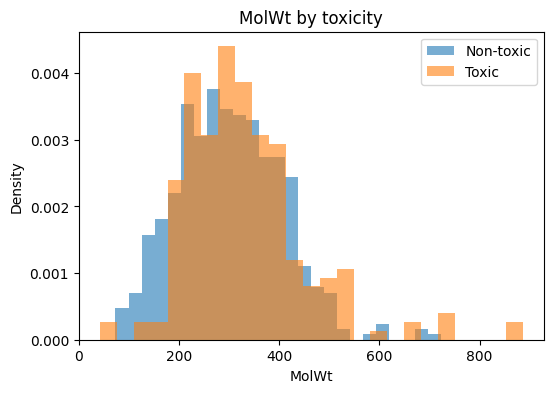

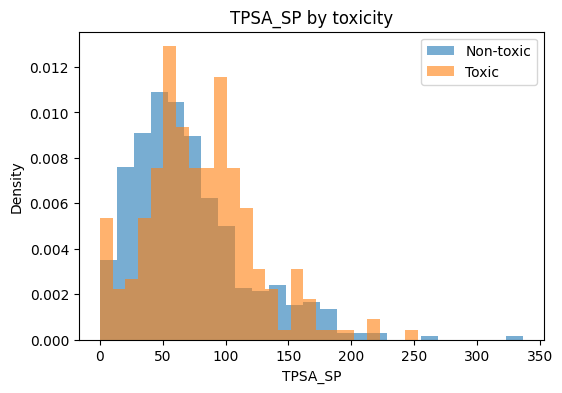

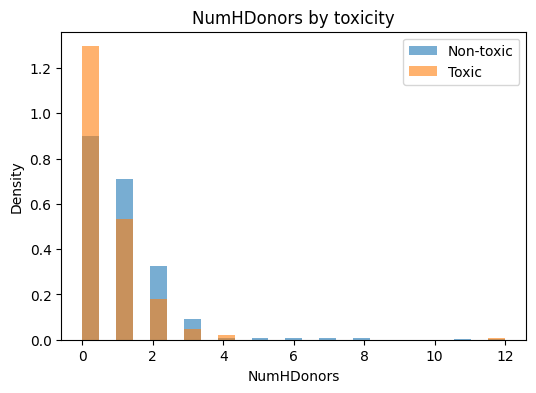

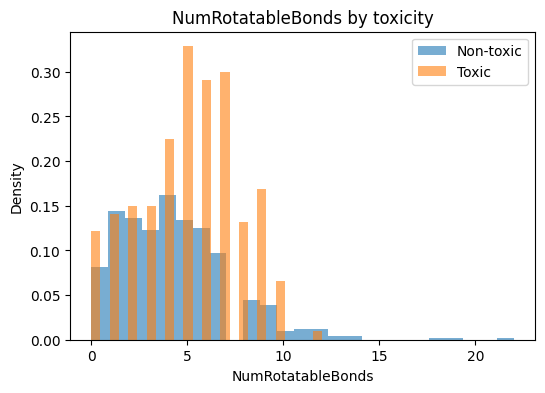

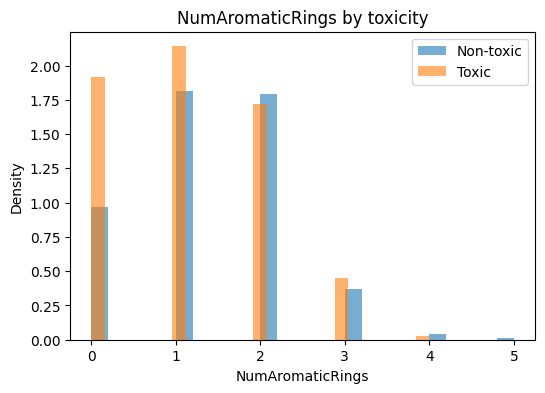

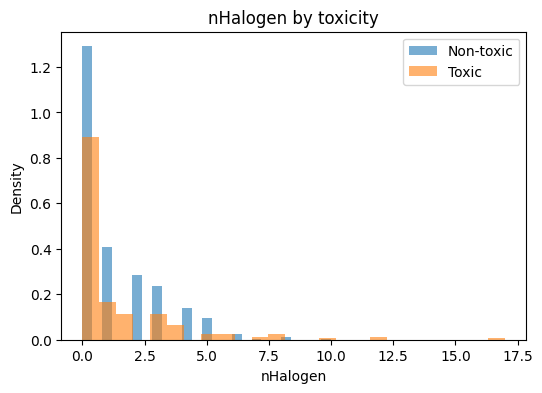

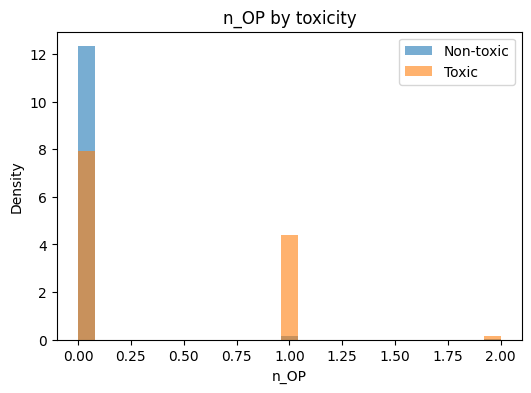

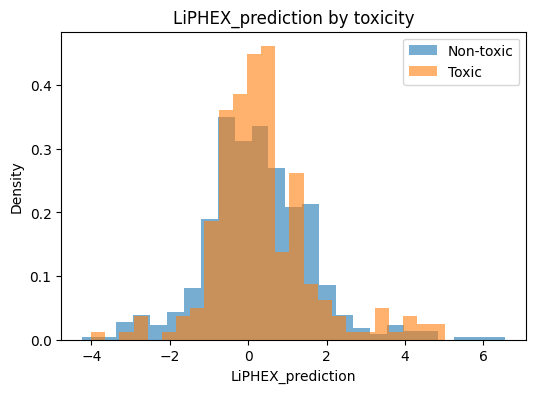

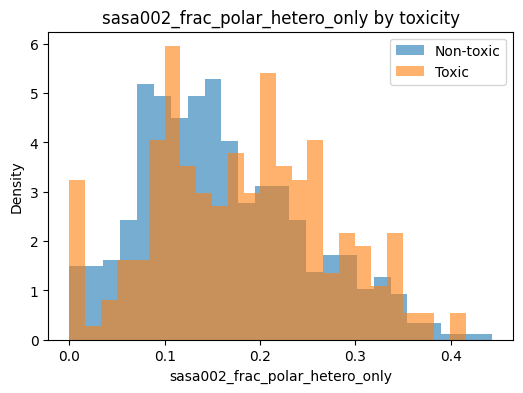

In [9]:
for feature in FEATURES:
    plt.figure(figsize=(6, 4))

    plt.hist(
        dev.loc[dev["LABEL"] == 0, feature],
        bins=25,
        alpha=0.6,
        density=True,
        label="Non-toxic"
    )

    plt.hist(
        dev.loc[dev["LABEL"] == 1, feature],
        bins=25,
        alpha=0.6,
        density=True,
        label="Toxic"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} by toxicity")
    plt.legend()
    plt.show()

### Interpretation of the class-conditional distributions

The classes overlap substantially for most descriptors, so no single ordinary physicochemical variable provides an obvious threshold separating toxic from non-toxic molecules.

The clearest tendencies are:

- **MolLogP:** toxic molecules are shifted toward somewhat higher lipophilicity.
- **MolWt:** toxic molecules are slightly heavier on average, but overlap is large.
- **TPSA / polar SASA:** toxic molecules show a modest shift toward greater polarity.
- **Hydrogen-bond donors:** toxic compounds are more concentrated at low donor counts, especially zero.
- **Rotatable bonds:** toxic compounds tend to have somewhat more rotatable bonds.
- **Aromatic rings / halogens:** differences are weaker and not obviously monotonic.
- **LiPHEX:** the two distributions overlap almost completely.
- **`n_OP`:** the discrete count clearly behaves differently from the other descriptors and is better examined with exact count tables below.

These patterns are hypotheses for later modeling, not evidence of causation.


## 3. Discrete/count descriptors

For integer-valued descriptors, a count table is more interpretable than a continuous-looking histogram.

**Why:** this lets us ask directly, for example, “among molecules with one `n_OP` motif, what fraction are toxic?” It also makes very small sample sizes visible, which prevents overinterpreting rare count values.


In [10]:
def toxicity_by_count(df, feature):
    out = (
        df.groupby(feature)["LABEL"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "sum": "toxic_n",
            "mean": "toxic_rate"
        })
    )
    return out

toxicity_by_count(dev, "n_OP")

,count,toxic_n,toxic_rate
n_OP,,,
0,624,141,0.225962
1,84,78,0.928571
2,4,3,0.750000


In [11]:
toxicity_by_count(dev, "nHalogen")

,count,toxic_n,toxic_rate
nHalogen,,,
0,388,135,0.347938
1,105,25,0.238095
2,73,17,0.232877
3,63,17,0.269841
4,37,10,0.270270
5,23,4,0.173913
6,9,4,0.444444
7,3,2,0.666667
8,6,4,0.666667


In [12]:
toxicity_by_count(dev, "NumAromaticRings")

,count,toxic_n,toxic_rate
NumAromaticRings,,,
0,163,68,0.417178
1,254,76,0.299213
2,237,61,0.257384
3,52,16,0.307692
4,5,1,0.200000
5,1,0,0.000000


In [13]:
toxicity_by_count(dev, "NumHDonors")

,count,toxic_n,toxic_rate
NumHDonors,,,
0,350,138,0.394286
1,224,57,0.254464
2,96,19,0.197917
3,27,5,0.185185
4,4,2,0.500000
5,2,0,0.000000
6,2,0,0.000000
7,2,0,0.000000
8,2,0,0.000000


### Interpretation of the count tables

`n_OP` is the most striking discrete descriptor:

- `n_OP = 0`: 624 molecules, **22.6% toxic**
- `n_OP = 1`: 84 molecules, **92.9% toxic**
- `n_OP = 2`: only 4 molecules, **75% toxic**

The `n_OP = 1` association is therefore strong, while `n_OP = 2` is too rare for a stable separate conclusion. This feature may capture a chemically meaningful mode-of-action family, but it could also make the prediction problem heavily dependent on that family; later analyses should therefore include an `n_OP` ablation and performance within the `n_OP = 0` subset.

Hydrogen-bond donor count shows a broad decrease in toxicity rate from 0 to 3 donors. Aromatic-ring and halogen counts show weaker/non-monotonic patterns, and very high counts have too few observations to interpret confidently.


## 4. Univariate predictive signal (single-feature AUROC)

**Question:** *How well could each descriptor rank toxic vs non-toxic molecules if it were used by itself?*

AUROC = 0.5 corresponds to no ranking ability. Values above or below 0.5 can both indicate separation; a value below 0.5 simply means that lower values are associated with toxicity. `separation_auc = max(AUC, 1-AUC)` is therefore used to compare strength independent of direction.

This is **not feature selection** and does not measure interactions between descriptors.


In [14]:
rows = []

for feature in FEATURES:
    auc = roc_auc_score(y, dev[feature])

    rows.append({
        "feature": feature,
        "auc": auc,
        "separation_auc": max(auc, 1 - auc),
        "direction": "higher -> toxic" if auc >= 0.5 else "lower -> toxic"
    })

univariate = (
    pd.DataFrame(rows)
    .sort_values("separation_auc", ascending=False)
)

univariate

,feature,auc,separation_auc,direction
7,n_OP,0.675014,0.675014,higher -> toxic
0,MolLogP,0.606688,0.606688,higher -> toxic
3,NumHDonors,0.397008,0.602992,lower -> toxic
4,NumRotatableBonds,0.602381,0.602381,higher -> toxic
2,TPSA_SP,0.588679,0.588679,higher -> toxic
9,sasa002_frac_polar_hetero_only,0.573083,0.573083,higher -> toxic
5,NumAromaticRings,0.433848,0.566152,lower -> toxic
1,MolWt,0.560797,0.560797,higher -> toxic
6,nHalogen,0.466382,0.533618,lower -> toxic
8,LiPHEX_prediction,0.507079,0.507079,higher -> toxic


### Interpretation

The strongest single-feature ranking signal is:

1. **`n_OP`** — separation AUROC ≈ **0.675**
2. **MolLogP** — ≈ **0.607**
3. **NumHDonors** — ≈ **0.603**, with *lower* values associated with toxicity
4. **NumRotatableBonds** — ≈ **0.602**

The remaining features have weaker individual ranking ability. `LiPHEX_prediction` is close to chance by itself (AUROC ≈ 0.507).

This does **not** mean weak univariate features should be removed: a descriptor can become useful through interactions or by contributing information that is complementary to other features.


## 5. Distributional tests

The Mann–Whitney U test compares the distributions of each descriptor between toxic and non-toxic molecules without assuming normality.

**Why:** many X10 variables are skewed or discrete, making a non-parametric comparison more appropriate than a simple t-test.

The p-values are descriptive here. With ten simultaneous tests, an inferential analysis should correct for multiple testing (for example Benjamini–Hochberg FDR), and practical effect size should be considered together with statistical significance.


In [15]:
results = []

for feature in FEATURES:
    x0 = dev.loc[dev["LABEL"] == 0, feature]
    x1 = dev.loc[dev["LABEL"] == 1, feature]

    U, p = stats.mannwhitneyu(
        x0,
        x1,
        alternative="two-sided"
    )

    results.append({
        "feature": feature,
        "median_non_toxic": x0.median(),
        "median_toxic": x1.median(),
        "mann_whitney_U": U,
        "p_value": p
    })

pd.DataFrame(results).sort_values("p_value")

,feature,median_non_toxic,median_toxic,mann_whitney_U,p_value
7,n_OP,0.000000,0.000000,35352.0,2.183477e-39
3,NumHDonors,1.000000,0.000000,65593.5,1.697191e-06
0,MolLogP,2.824980,3.506800,42784.5,5.001025e-06
4,NumRotatableBonds,4.000000,5.000000,43253.0,1.056582e-05
2,TPSA_SP,61.405000,75.990000,44743.5,1.480344e-04
9,sasa002_frac_polar_hetero_only,0.147566,0.181801,46440.0,1.766407e-03
5,NumAromaticRings,1.000000,1.000000,61586.0,2.933717e-03
1,MolWt,298.920500,313.794500,47776.5,9.290440e-03
6,nHalogen,0.000000,0.000000,58047.0,1.150648e-01
8,LiPHEX_prediction,0.205582,0.201751,53620.0,7.621357e-01


### Interpretation

The Mann–Whitney results are broadly consistent with the distribution plots: `n_OP`, hydrogen-bond donors, MolLogP, rotatable bonds, TPSA, polar SASA, aromatic rings, and molecular weight show evidence of different class distributions.

Two useful cautions:

- `nHalogen` and `LiPHEX_prediction` do not show convincing univariate distribution differences here.
- `n_OP` has a median of **0 in both classes**, yet an extremely small p-value. This illustrates why the median alone is insufficient: the signal comes from the relatively small but highly toxicity-enriched group with `n_OP > 0`.

P-values should not be converted directly into claims of predictive importance.


## 6. Correlation and redundancy

Spearman correlation is used because it measures **monotonic association** and is less dependent on normality than Pearson correlation.

**Why:** strongly correlated descriptors may encode overlapping information. This matters for interpretation, linear-model coefficients, dimensionality reduction, and later feature-ablation experiments.


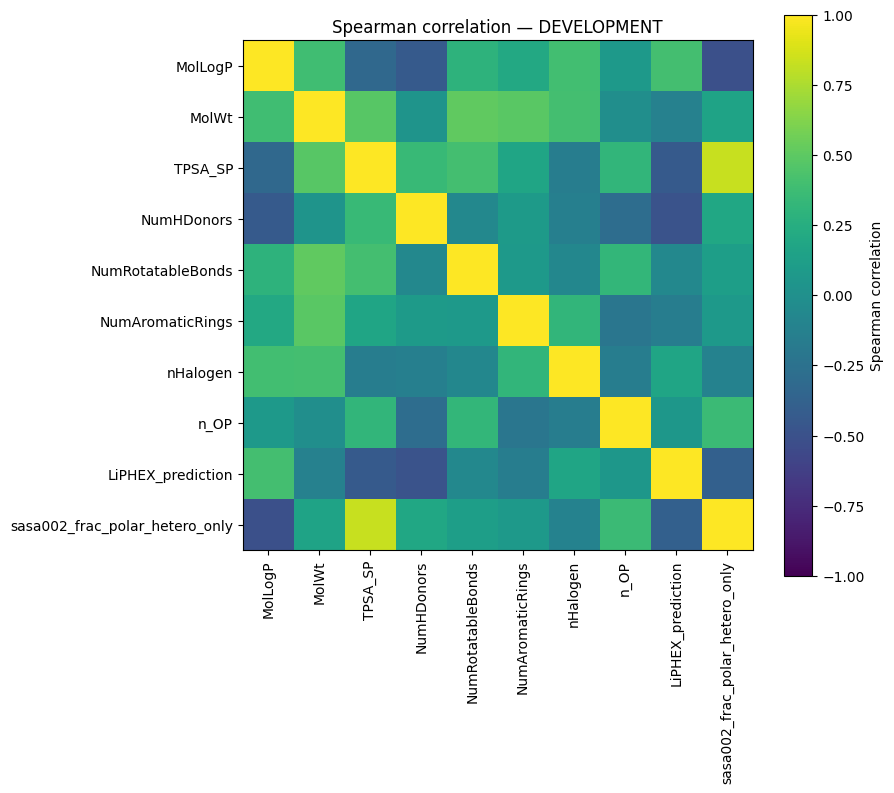

In [16]:
corr = dev[FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90)
ax.set_yticklabels(FEATURES)

plt.colorbar(im, ax=ax, label="Spearman correlation")
plt.title("Spearman correlation — DEVELOPMENT")
plt.tight_layout()
plt.show()

### Strongest correlated pairs

The largest absolute correlations are extracted explicitly so that redundancy can be discussed quantitatively rather than only from the heatmap.

> A high correlation is a reason to investigate redundancy, **not an automatic reason to delete a feature**.


In [17]:
pairs = []

for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        pairs.append({
            "feature_1": FEATURES[i],
            "feature_2": FEATURES[j],
            "rho": corr.iloc[i, j],
            "abs_rho": abs(corr.iloc[i, j])
        })

pd.DataFrame(pairs).sort_values("abs_rho", ascending=False).head(15)

,feature_1,feature_2,rho,abs_rho
23,TPSA_SP,sasa002_frac_polar_hetero_only,0.833634,0.833634
8,MolLogP,sasa002_frac_polar_hetero_only,-0.514667,0.514667
11,MolWt,NumRotatableBonds,0.509947,0.509947
28,NumHDonors,LiPHEX_prediction,-0.489169,0.489169
12,MolWt,NumAromaticRings,0.487684,0.487684
9,MolWt,TPSA_SP,0.483801,0.483801
2,MolLogP,NumHDonors,-0.435420,0.435420
22,TPSA_SP,LiPHEX_prediction,-0.433000,0.433000
7,MolLogP,LiPHEX_prediction,0.404835,0.404835
13,MolWt,nHalogen,0.404650,0.404650


### Interpretation

The strongest redundancy is between:

- **TPSA_SP and polar SASA:** Spearman ρ ≈ **0.834**

This is chemically plausible because both describe molecular polarity/surface exposure. Other moderate associations include:

- MolLogP vs polar SASA: ρ ≈ **−0.515**
- MolWt vs rotatable bonds: ρ ≈ **0.510**
- H-donors vs LiPHEX: ρ ≈ **−0.489**
- MolWt vs aromatic rings: ρ ≈ **0.488**

No feature should be deleted solely because of this heatmap. The strong TPSA–SASA pair is instead a good candidate for later ablation or coefficient-stability analysis.


## 7. Mutual information

**Question:** *Does a feature contain information about the label even when the relationship is not simply linear or monotonic?*

Mutual information (MI) complements the univariate AUROC and distribution plots. MI values are estimator-dependent and can be noisy at this sample size, so they should be interpreted comparatively rather than as absolute effect sizes.


In [51]:
discrete_mask = [
    False,  # MolLogP
    False,  # MolWt
    False,  # TPSA
    True,   # HDonors
    True,   # Rotatable bonds
    True,   # Aromatic rings
    True,   # Halogens
    True,   # n_OP
    False,  # LiPHEX
    False,  # SASA
]

mi = mutual_info_classif(
    dev[FEATURES],
    y,
    discrete_features=discrete_mask,
    random_state=SEED
)

mi_df = pd.DataFrame({
    "feature": FEATURES,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False)

mi_df

,feature,mutual_information
7,n_OP,0.118707
2,TPSA_SP,0.098521
4,NumRotatableBonds,0.030260
1,MolWt,0.026240
3,NumHDonors,0.021338
6,nHalogen,0.016302
8,LiPHEX_prediction,0.012743
5,NumAromaticRings,0.008893
0,MolLogP,0.000795
9,sasa002_frac_polar_hetero_only,0.000000


### Interpretation

Estimated mutual information is highest for:

- **`n_OP` ≈ 0.119**
- **TPSA_SP ≈ 0.099**

The remaining features are substantially lower in this estimator.

The disagreement between some metrics is itself informative. For example, MolLogP has useful univariate AUROC (~0.607) but near-zero estimated MI here. MI estimation can be noisy and sensitive to how continuous/discrete variables are handled, so no single statistic should drive feature selection.


## 8. Principal Component Analysis (PCA)

PCA creates new orthogonal variables (principal components) that summarize the major **linear directions of variation** in X10.

The ten descriptors are standardized first because they have very different units and numerical scales. PCA is **unsupervised**: toxicity labels are not used to construct the components.

Important: PCA maximizes explained variance, not toxicity discrimination. A low-variance component can still contain useful predictive information.


In [58]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(dev[FEATURES])

pca = PCA(svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_variance = pd.DataFrame({
    "PC": np.arange(1, len(FEATURES) + 1),
    "explained_variance": explained,
    "cumulative_variance": cumulative
})

pca_variance

,PC,explained_variance,cumulative_variance
0,1,0.319569,0.319569
1,2,0.214618,0.534187
2,3,0.157856,0.692043
3,4,0.096416,0.788459
4,5,0.081817,0.870276
5,6,0.048642,0.918918
6,7,0.037363,0.956281
7,8,0.026976,0.983257
8,9,0.013638,0.996895
9,10,0.003105,1.000000


### Interpretation of explained variance

The first components explain:

- **PC1:** 32.0%
- **PC2:** 21.5%
- **PC3:** 15.8%
- **PC1 + PC2:** 53.4%
- **PC1–PC3:** 69.2%
- **PC1–PC5:** 87.0%

X10 therefore has substantial lower-dimensional structure, but it is not well summarized by only two components. In particular, later loading analysis shows that an important feature (`n_OP`) is represented mainly by PC3, illustrating why “highest variance” is not the same as “highest predictive relevance.”


### Explained variance / scree plot

**Why:** the scree plot shows how much of the original X10 variation is retained as additional PCs are included. This tells us how compressible the descriptor space is, but it does **not** by itself tell us how many PCs should be used for prediction.


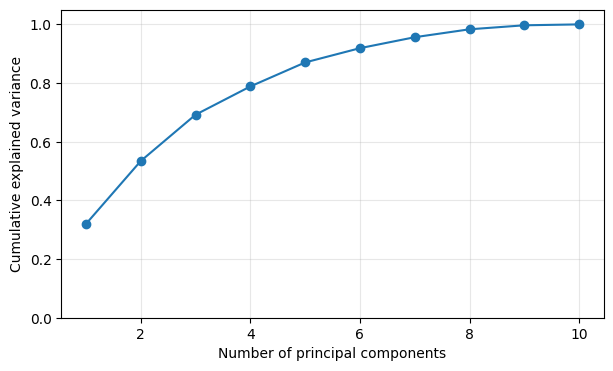

In [59]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(FEATURES) + 1),
    cumulative,
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

### PC1 vs PC2 colored by toxicity

**Why:** this projection asks whether the two dominant linear directions of molecular variation visibly organize toxic and non-toxic compounds.

Because PC1 and PC2 together retain only part of X10, absence of visual separation here is not evidence that the full representation cannot predict toxicity.


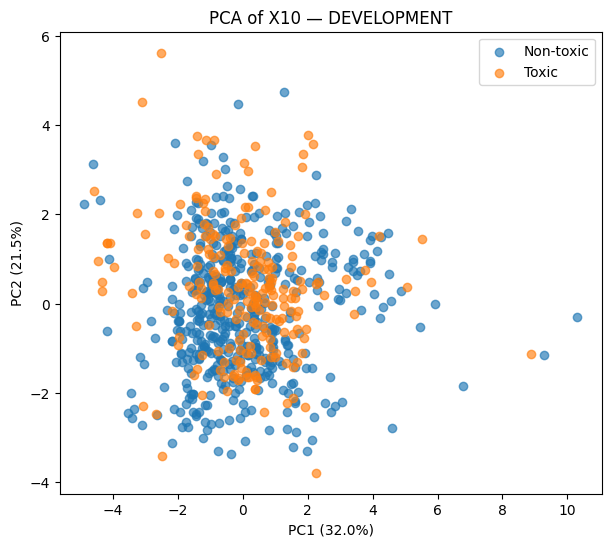

In [60]:
plt.figure(figsize=(7, 6))

for label, name in [(0, "Non-toxic"), (1, "Toxic")]:
    mask = y.values == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.65,
        label=name
    )

plt.xlabel(f"PC1 ({explained[0]:.1%})")
plt.ylabel(f"PC2 ({explained[1]:.1%})")
plt.legend()
plt.title("PCA of X10 — DEVELOPMENT")
plt.show()

### Interpretation

Toxic and non-toxic compounds overlap strongly in PC1–PC2 space.

This means that the **two dominant linear directions of X10 variation do not trivially separate the classes**. It does *not* mean X10 is non-predictive: PCA never saw the labels, PC1+PC2 retain only 53.4% of the total variance, and predictive relationships can be nonlinear or reside in later components.


### PCA loadings

The loading coefficients show which original descriptors define each principal component. Larger absolute coefficients mean a stronger contribution to that component.

The sign indicates opposite directions within a PC, but the overall sign of a principal component is arbitrary: multiplying an entire PC by −1 would represent the same PCA solution.


In [62]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=[f"PC{i}" for i in range(1, 11)]
)

loadings[["PC1", "PC2", "PC3"]]

,PC1,PC2,PC3
MolLogP,-0.399322,0.396252,0.118434
MolWt,0.137475,0.601942,-0.120381
TPSA_SP,0.505991,0.218015,0.085414
NumHDonors,0.387138,-0.045446,-0.310343
NumRotatableBonds,0.095438,0.397158,0.388256
NumAromaticRings,0.039064,0.372688,-0.344963
nHalogen,-0.195376,0.354951,-0.272216
n_OP,0.084470,0.073948,0.673785
LiPHEX_prediction,-0.415016,0.046117,0.182713
sasa002_frac_polar_hetero_only,0.433083,0.028956,0.191466


In [63]:
loadings["PC1"].sort_values(key=abs, ascending=False)

TPSA_SP                           0.505991
sasa002_frac_polar_hetero_only    0.433083
LiPHEX_prediction                -0.415016
MolLogP                          -0.399322
NumHDonors                        0.387138
nHalogen                         -0.195376
MolWt                             0.137475
NumRotatableBonds                 0.095438
n_OP                              0.084470
NumAromaticRings                  0.039064
Name: PC1, dtype: float64

In [64]:
loadings["PC2"].sort_values(key=abs, ascending=False)

MolWt                             0.601942
NumRotatableBonds                 0.397158
MolLogP                           0.396252
NumAromaticRings                  0.372688
nHalogen                          0.354951
TPSA_SP                           0.218015
n_OP                              0.073948
LiPHEX_prediction                 0.046117
NumHDonors                       -0.045446
sasa002_frac_polar_hetero_only    0.028956
Name: PC2, dtype: float64

In [65]:
loadings["PC3"].sort_values(key=abs, ascending=False)

n_OP                              0.673785
NumRotatableBonds                 0.388256
NumAromaticRings                 -0.344963
NumHDonors                       -0.310343
nHalogen                         -0.272216
sasa002_frac_polar_hetero_only    0.191466
LiPHEX_prediction                 0.182713
MolWt                            -0.120381
MolLogP                           0.118434
TPSA_SP                           0.085414
Name: PC3, dtype: float64

### Interpretation of the first three PCs

The loadings give the first three components a useful chemical interpretation:

- **PC1 — polarity vs lipophilicity.** TPSA, polar SASA, and H-donors load in one direction, while MolLogP and LiPHEX load in the opposite direction.
- **PC2 — molecular size / complexity.** Molecular weight is dominant, with rotatable bonds, aromatic rings, MolLogP, and halogen count also contributing.
- **PC3 — organophosphorus-related structural dimension.** `n_OP` has by far the largest loading (**0.674**), with smaller contributions from rotatable bonds, aromatic rings, H-donors, and halogens.

Thus, the explicit organophosphorus motif carries a dimension that is not captured strongly by the two dominant global physicochemical PCs.


### PCA colored by the organophosphorus-like motif count (`n_OP`)

This is the **same PCA geometry**, but color now represents `n_OP` rather than toxicity.

**Why:** it helps determine whether the explicit organophosphorus structural descriptor corresponds to one of the major directions of variation or occupies a more specific part of X10 space.


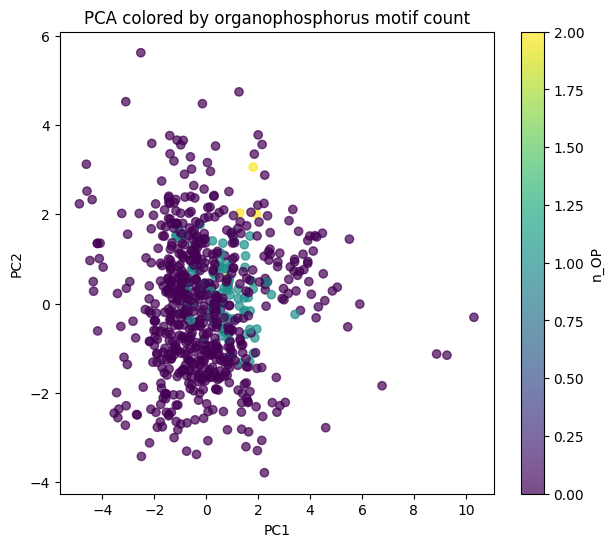

In [66]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dev["n_OP"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="n_OP")
plt.title("PCA colored by organophosphorus motif count")
plt.show()

### Interpretation

Most `n_OP > 0` molecules do not separate dramatically in PC1–PC2. This is exactly what the loadings predict: `n_OP` contributes very little to PC1 (~0.084) and PC2 (~0.074), but strongly to PC3 (~0.674).

Therefore, PC1–PC2 is not the most informative PCA projection for visualizing this motif. PC1–PC3 or PC2–PC3 would be more appropriate if the goal is specifically to visualize the `n_OP` axis.


## 9. UMAP on X10

UMAP is used as a nonlinear visualization of the standardized X10 descriptor space. Unlike PCA, it can reveal local nonlinear neighborhoods that are difficult to see in a linear projection.

The embedding is still **unsupervised**: toxicity and `n_OP` are used only to color the already-computed coordinates.

UMAP is exploratory. Apparent clusters should not be treated as formal evidence because the result depends on parameters such as `n_neighbors`, `min_dist`, metric, and random seed.


In [27]:
%pip install umap-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    metric="euclidean",
    random_state=SEED,
    n_jobs=1
)

X_umap = reducer.fit_transform(X_scaled)

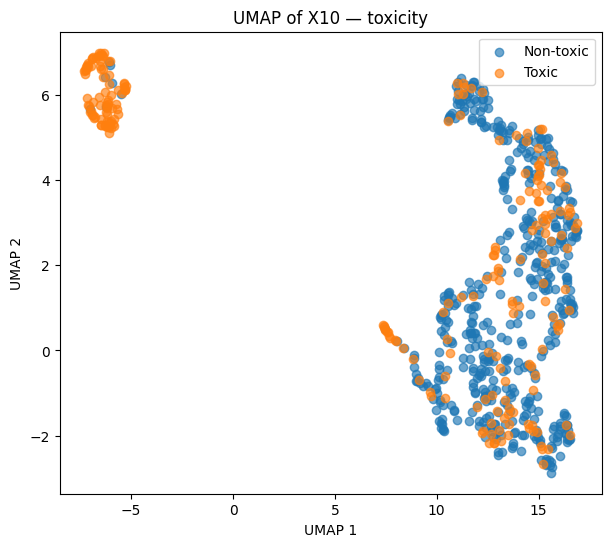

In [69]:
plt.figure(figsize=(7, 6))

for label, name in [(0, "Non-toxic"), (1, "Toxic")]:
    mask = y.values == label

    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        alpha=0.65,
        label=name
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.title("UMAP of X10 — toxicity")
plt.show()

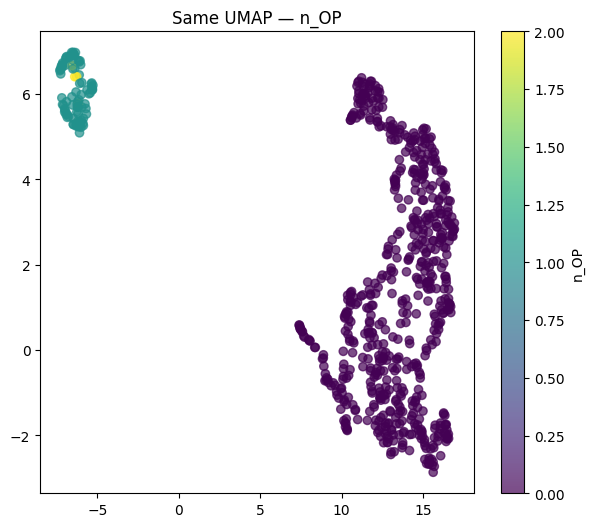

In [70]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=dev["n_OP"],
    alpha=0.7
)

plt.colorbar(scatter, label="n_OP")
plt.title("Same UMAP — n_OP")
plt.show()

### Interpretation of the X10 UMAP

The X10 UMAP contains a clearly separated left-hand island. Coloring the **same coordinates** by `n_OP` shows that this island corresponds almost entirely to molecules with `n_OP > 0`; coloring by toxicity shows that it is also strongly enriched in toxic molecules.

This is consistent with the count-table, AUROC, MI, and PCA-loading results: the organophosphorus-like motif is a major source of signal in X10.

However, this should not be interpreted as proof of a distinct biological toxicity class. `n_OP` is sparse, and after standardization its rare non-zero values are far from the majority value of zero, so it can strongly influence Euclidean UMAP geometry. A useful sensitivity analysis is to recompute the UMAP without `n_OP` and check what structure remains.

The large `n_OP = 0` region still contains both classes, indicating that the remaining prediction problem is not explained by this motif alone.


### UMAP of Morgan fingerprints (structural chemical space)

The previous UMAP describes similarity in the **ten X10 descriptors**. This second UMAP asks a different question:

> **Which molecules are similar in 2D molecular substructure space?**

Morgan/ECFP fingerprints represent local molecular environments directly, so this visualization is useful for comparing the compact X10 geometry with molecular structural geometry.


In [31]:
%pip install rdkit -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

fpgen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=1024,
    includeChirality=True
)

fps = []

for smi in dev["SMILES"]:
    mol = Chem.MolFromSmiles(smi)
    fp = fpgen.GetFingerprintAsNumPy(mol)
    fps.append(fp)

X_fp = np.asarray(fps, dtype=bool)

### Binary-set distance

For binary Morgan fingerprints, Jaccard/Tanimoto-style comparison focuses on the **substructures that are present** rather than treating thousands of shared absent bits as evidence of similarity.

Using `metric="jaccard"` therefore gives UMAP a distance that is natural for binary molecular fingerprints.


In [71]:
struct_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",
    random_state=SEED,
    n_jobs=1
)

X_struct_umap = struct_umap.fit_transform(X_fp)

C:\Users\Andres\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


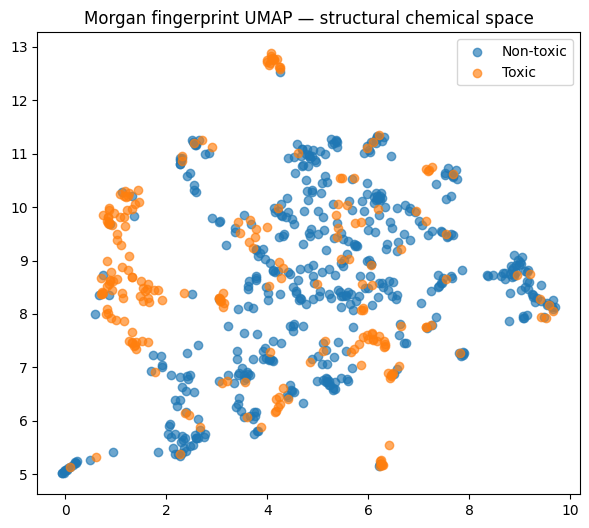

In [72]:
plt.figure(figsize=(7, 6))

for label, name in [(0, "Non-toxic"), (1, "Toxic")]:
    mask = y.values == label

    plt.scatter(
        X_struct_umap[mask, 0],
        X_struct_umap[mask, 1],
        alpha=0.65,
        label=name
    )

plt.legend()
plt.title("Morgan fingerprint UMAP — structural chemical space")
plt.show()

### Interpretation of structural-space UMAP

The Morgan-fingerprint UMAP forms many local islands rather than one continuous cloud. Several regions are strongly enriched for one toxicity class, while many others remain mixed.

This suggests that **molecular structural families contain toxicity-related information**, but structure does not produce a single simple global toxic/non-toxic separation.

Unlike X10 UMAP, this embedding is based on thousands of local substructure indicators rather than ten global descriptors. UMAP is most trustworthy for local-neighborhood exploration; distances between far-apart islands should not be interpreted quantitatively. The nearest-Tanimoto analysis later in the notebook provides a more direct structural-distance measure.


## 10. Butina structural-cluster analysis

The DEVELOPMENT molecules already have Butina cluster IDs derived from Morgan fingerprints.

**Why:** inspecting these clusters tells us how much the dataset consists of close structural analogues and whether structural families tend to share toxicity labels. This directly informs the risk of overly optimistic evaluation if related molecules are allowed to cross train/validation boundaries.


In [36]:
cluster_stats = (
    dev.groupby("BUTINA_CLUSTER_ID")
    .agg(
        size=("LABEL", "size"),
        toxic_n=("LABEL", "sum"),
        toxic_rate=("LABEL", "mean")
    )
    .sort_values("size", ascending=False)
)

cluster_stats.head(20)

,size,toxic_n,toxic_rate
BUTINA_CLUSTER_ID,,,
0,40,5,0.125000
4,17,16,0.941176
3,17,1,0.058824
6,14,0,0.000000
11,11,0,0.000000
12,11,9,0.818182
8,11,0,0.000000
9,11,11,1.000000
18,9,7,0.777778


### Structural cluster-size distribution

A cluster-size histogram shows whether the chemical domain is dominated by a few large analogue series or by many small/singleton structural families.


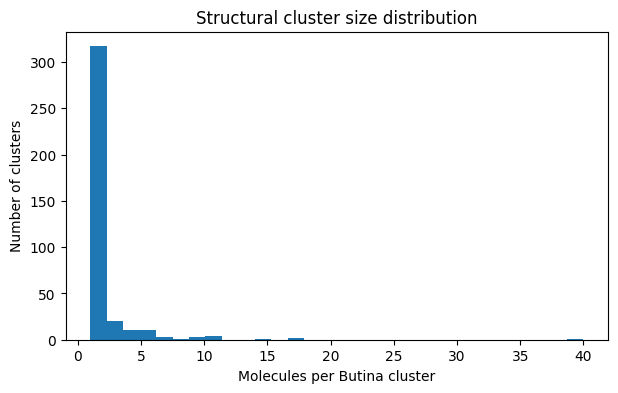

In [37]:
plt.figure(figsize=(7, 4))
plt.hist(cluster_stats["size"], bins=30)
plt.xlabel("Molecules per Butina cluster")
plt.ylabel("Number of clusters")
plt.title("Structural cluster size distribution")
plt.show()

In [38]:
cluster_stats[cluster_stats["size"] >= 3].sort_values(
    "toxic_rate",
    ascending=False
)

,size,toxic_n,toxic_rate
BUTINA_CLUSTER_ID,,,
9,11,11,1.000000
38,5,5,1.000000
56,5,5,1.000000
31,7,7,1.000000
17,9,9,1.000000
58,4,4,1.000000
59,4,4,1.000000
63,4,4,1.000000
30,5,5,1.000000


### Interpretation

DEVELOPMENT is structurally diverse:

- **374** Butina clusters for 712 molecules
- **272 clusters (72.7%) are singletons**
- **317 clusters (84.8%) contain at most two molecules**
- the largest cluster contains **40 molecules**

At the same time, some non-trivial clusters are highly label-specific. Examples include an 11-molecule cluster with 11 toxic compounds, another 11-molecule cluster with 0 toxic compounds, and two 17-molecule clusters with 16/17 toxic vs 1/17 toxic.

This is exactly why ordinary random cross-validation could be optimistic: a close analogue in training may make a validation molecule much easier to classify.


### Cluster label purity

For each non-singleton Butina cluster, purity is the fraction belonging to the majority toxicity class:

`purity = max(toxic_rate, 1 - toxic_rate)`.

**Why:** high purity means that close structural analogues often share the same label, which strengthens the case for cluster-aware evaluation. Singleton clusters are excluded because they have 100% purity by definition and would inflate the statistic.


In [39]:
cluster_stats["purity"] = np.maximum(
    cluster_stats["toxic_rate"],
    1 - cluster_stats["toxic_rate"]
)

cluster_stats.loc[
    cluster_stats["size"] >= 2,
    ["size", "toxic_rate", "purity"]
].describe()

,size,toxic_rate,purity
count,102.000000,102.000000,102.000000
mean,4.313725,0.379862,0.883751
std,4.728218,0.407981,0.179726
min,2.000000,0.000000,0.500000
25%,2.000000,0.000000,0.800000
50%,3.000000,0.200000,1.000000
75%,4.750000,0.794444,1.000000
max,40.000000,1.000000,1.000000


### Interpretation

Among the **102 clusters with at least two molecules**, mean label purity is about **0.884** and median purity is **1.0**.

That indicates that many structural analogue groups are dominated by one toxicity label, supporting the use of group/cluster-aware validation.

The statistic must still be interpreted cautiously: most clusters are very small, and small clusters can achieve high purity by chance. The result supports the evaluation design; it does not imply that structure alone determines toxicity.


## 11. DEVELOPMENT vs TEST descriptor shift

This analysis compares the **X10 feature distributions** between DEVELOPMENT and TEST without using TEST labels.

Two complementary quantities are calculated:

- **Standardized mean difference (SMD):** magnitude and direction of the mean shift in standard-deviation units.
- **Kolmogorov–Smirnov statistic (KS):** difference between the full empirical distributions.

**Why:** a structure-aware split may also produce physicochemical covariate shift. Understanding that shift is necessary when interpreting held-out performance.


In [40]:
shift = []

for feature in FEATURES:
    a = dev[feature]
    b = test[feature]

    pooled_sd = np.sqrt(
        (
            (len(a) - 1) * a.var()
            + (len(b) - 1) * b.var()
        )
        / (len(a) + len(b) - 2)
    )

    smd = (b.mean() - a.mean()) / pooled_sd

    ks_stat, ks_p = stats.ks_2samp(a, b)

    shift.append({
        "feature": feature,
        "dev_mean": a.mean(),
        "test_mean": b.mean(),
        "standardized_mean_difference": smd,
        "KS": ks_stat,
        "KS_p": ks_p
    })

shift = pd.DataFrame(shift)
shift.sort_values(
    "standardized_mean_difference",
    key=abs,
    ascending=False
)

,feature,dev_mean,test_mean,standardized_mean_difference,KS,KS_p
6,nHalogen,1.245787,1.944751,0.347758,0.213452,2.993091e-06
0,MolLogP,2.962598,3.347167,0.184691,0.222438,9.430619e-07
1,MolWt,311.075770,331.107956,0.173098,0.142847,4.882060e-03
7,n_OP,0.129213,0.071823,-0.169472,0.057297,7.041342e-01
5,NumAromaticRings,1.276685,1.425414,0.156692,0.089810,1.815781e-01
3,NumHDonors,0.842697,1.038674,0.120186,0.022550,9.999976e-01
9,sasa002_frac_polar_hetero_only,0.166373,0.157152,-0.105348,0.118412,3.168820e-02
2,TPSA_SP,73.774860,71.338785,-0.046904,0.144927,4.087318e-03
8,LiPHEX_prediction,0.302571,0.266054,-0.027309,0.061953,6.101047e-01
4,NumRotatableBonds,4.539326,4.602210,0.021444,0.120678,2.700540e-02


### Interpretation of DEVELOPMENT–TEST shift

The largest standardized mean shift is for **halogen count** (SMD ≈ +0.35), with TEST containing more halogens on average. Smaller shifts appear for MolLogP (+0.18), molecular weight (+0.17), `n_OP` (−0.17), and aromatic rings (+0.16).

Most feature-level SMDs are small to modest, so the structural split did **not** create a wholesale separation in X10 physicochemical space. TEST is somewhat more halogenated, lipophilic, and heavy on average, and contains fewer `n_OP` centers.

Several KS p-values are small, but effect size is more useful here than significance alone; with hundreds of observations, modest distributional differences can become statistically significant.


### PCA projection of DEVELOPMENT and TEST

The scaler and PCA are fitted **only on DEVELOPMENT**, then TEST is projected into that fixed coordinate system.

**Why:** this gives a visual diagnostic of whether TEST occupies the same broad X10 physicochemical domain, while avoiding the use of TEST data to define the PCA axes.


In [77]:
scaler = StandardScaler()
X_dev_scaled = scaler.fit_transform(dev[FEATURES])
X_test_scaled = scaler.transform(test[FEATURES])

pca = PCA(n_components=2, svd_solver="full")

Z_dev = pca.fit_transform(X_dev_scaled)
Z_test = pca.transform(X_test_scaled)

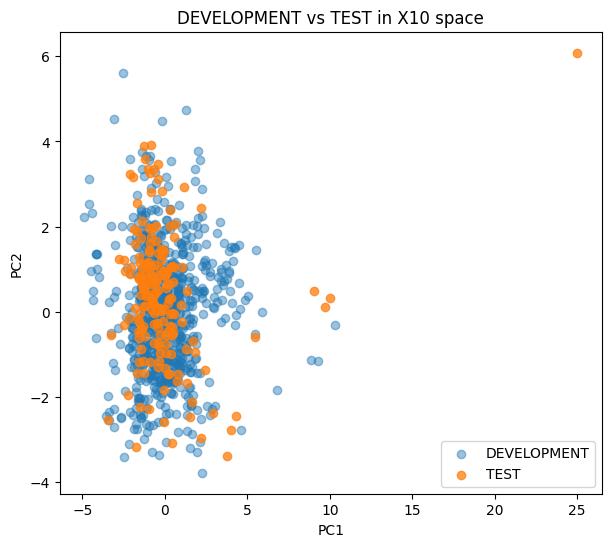

In [78]:
plt.figure(figsize=(7, 6))

plt.scatter(
    Z_dev[:, 0],
    Z_dev[:, 1],
    alpha=0.45,
    label="DEVELOPMENT"
)

plt.scatter(
    Z_test[:, 0],
    Z_test[:, 1],
    alpha=0.75,
    label="TEST"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("DEVELOPMENT vs TEST in X10 space")
plt.show()

### Interpretation

DEVELOPMENT and TEST overlap strongly in the first two DEVELOPMENT-defined PCA axes, which supports the idea that both sets occupy the same broad X10 physicochemical domain.

At the same time, TEST contains a few clear extreme projections, including one very large PC1 value. These molecules may be particularly informative for later error/applicability-domain analysis.

The important distinction is that **structural novelty does not necessarily imply large separation in ten global descriptors**: two molecules can have similar size/polarity properties while having very different molecular substructures.


## 12. Nearest-neighbor Tanimoto similarity

For each TEST molecule, find the DEVELOPMENT molecule with the highest Morgan-fingerprint Tanimoto similarity.

**Question:** *How structurally novel is each held-out molecule relative to the closest molecule available during development?*

This is a quantitative complement to UMAP and to the statement that DEVELOPMENT and TEST are cluster-disjoint.


In [79]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

fpgen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=1024,
    includeChirality=True
)

def make_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return fpgen.GetFingerprint(mol)

dev_fps = [make_fp(s) for s in dev["SMILES"]]
test_fps = [make_fp(s) for s in test["SMILES"]]

nearest_similarity = []

for fp in test_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, dev_fps)
    nearest_similarity.append(max(sims))

test_similarity = test[
    ["ID", "name", "SMILES"]
].copy()

test_similarity["nearest_dev_tanimoto"] = nearest_similarity

test_similarity.sort_values("nearest_dev_tanimoto")

,ID,name,SMILES,nearest_dev_tanimoto
427,482,Mepiquat,C[N+]1(C)CCCCC1,0.142857
663,733,Polyoxin B,NC(=O)OCC(O)C(O)C(N)C(=O)NC(C(=O)O)C1OC(n2cc(C...,0.166667
738,832,"(1alpha,2alpha,3beta,4alpha,5alpha,6beta)-1,2,...",ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl,0.166667
827,957,Mildiomycin (Ref: AR-1F1870),NC(N)=NCC(O)CC(O)(C(=O)O)C1OC(n2cc(CO)c(N)nc2=...,0.172414
398,453,Polyoxorim,NC(=O)OCC(O)C(O)C(N)C(=O)NC(C(=O)O)C1OC(n2cc(C...,0.178571
...,...,...,...,...
515,574,Haloxyfop-P-methyl (Ref: DE 535),COC(=O)C(C)Oc1ccc(Oc2ncc(C(F)(F)F)cc2Cl)cc1,0.740741
346,395,alpha-(2-Chlorophenyl)-alpha-(4-chlorophenyl)-...,OC(c1ccc(Cl)cc1)(c1cncnc1)c1ccccc1Cl,0.783784
719,804,4-Amino-3-chloro-6-(4-chloro-2-fluoro-3-methox...,COC(=O)c1nc(-c2ccc(Cl)c(OC)c2F)cc(N)c1Cl,0.808511
605,668,"N-(2,6-Dichlorophenyl)-5-ethoxy-7-fluoro-[1,2,...",CCOc1nc(F)cc2nc(S(=O)(=O)Nc3c(Cl)cccc3Cl)nn12,0.810345


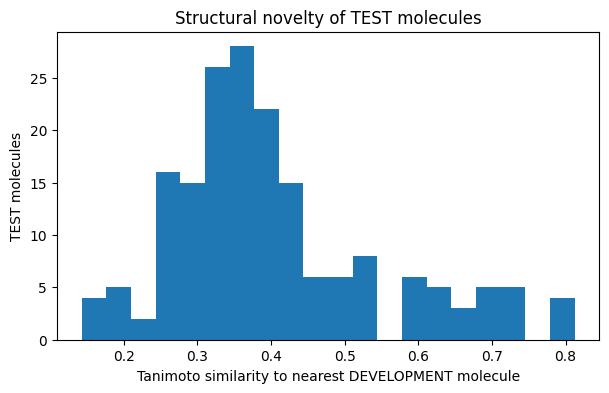

In [80]:
plt.figure(figsize=(7, 4))

plt.hist(
    test_similarity["nearest_dev_tanimoto"],
    bins=20
)

plt.xlabel("Tanimoto similarity to nearest DEVELOPMENT molecule")
plt.ylabel("TEST molecules")
plt.title("Structural novelty of TEST molecules")
plt.show()

### Interpretation of structural novelty

Nearest-DEVELOPMENT Tanimoto similarity for the 181 TEST molecules is approximately:

- **mean:** 0.405
- **median:** 0.371
- **25th–75th percentile:** 0.314–0.463
- **range:** 0.143–0.813

About **61%** of TEST molecules have nearest similarity below 0.40, while only about **13%** have a nearest DEVELOPMENT analogue at or above 0.60.

This supports the characterization of TEST as meaningfully structure-aware: many held-out molecules are only moderately or weakly similar to anything in DEVELOPMENT. However, novelty is heterogeneous; some TEST compounds still have fairly close analogues, so the holdout should be described as **cluster-disjoint**, not as uniformly or mathematically strict OOD.


The histogram is the actual distribution of structural similarity between each held-out molecule and its closest DEVELOPMENT analogue.

This is more informative than simply saying that the partitions have zero Butina-cluster overlap: cluster-disjoint does **not** imply that every TEST molecule is equally distant from DEVELOPMENT.

A useful later extension is to relate model error, confidence, and calibration to nearest-training Tanimoto similarity. That becomes an **applicability-domain analysis**: does prediction quality degrade as structural novelty increases?


## Phase 0 synthesis

The main EDA findings are:

1. **No single ordinary physicochemical descriptor cleanly separates toxicity.** Most toxic/non-toxic distributions overlap substantially.
2. **`n_OP` is exceptional.** It is sparse but strongly associated with toxicity and defines a distinct axis/region in PCA and UMAP. This is useful signal, but it should be stress-tested with `n_OP` ablation and `n_OP = 0` subgroup performance.
3. **X10 has interpretable latent structure.** PC1 broadly represents polarity/lipophilicity, PC2 molecular size/complexity, and PC3 is strongly organophosphorus-related.
4. **The first two PCs are not class-separating.** This argues against assuming that a simple two-dimensional linear representation captures the toxicity problem.
5. **Structural families matter.** Butina clusters are mostly small, but non-singleton clusters are often label-homogeneous, supporting cluster-aware cross-validation.
6. **TEST remains broadly similar in X10 space but is structurally more novel.** Nearest-neighbor Tanimoto similarities are mostly modest, which makes structural-generalization performance an important part of the later model evaluation.

These results do not select a final model. Instead, they define the questions the modeling phase should answer: linear vs nonlinear signal, dependence on the organophosphorus motif, robustness across structural families, and performance as molecular novelty increases.
